In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay
)
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from xgboost import XGBClassifier

# Plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.color':       '#e0e0e0',
    'grid.linewidth':   0.7,
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
})

PALETTE  = ['#E24B4A', '#EF9F27', '#1D9E75']   # Underdeveloped / Developing / Developed
KM_COLORS = ['#378ADD', '#D85A30', '#639922', '#7F77DD']

print('All imports successful ✓')

All imports successful ✓


In [22]:
df = pd.read_csv('Country-data.csv')
print(f'Shape: {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')
df.head()

Shape: (167, 10)
Missing values: 0


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [23]:
df.describe().round(2)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


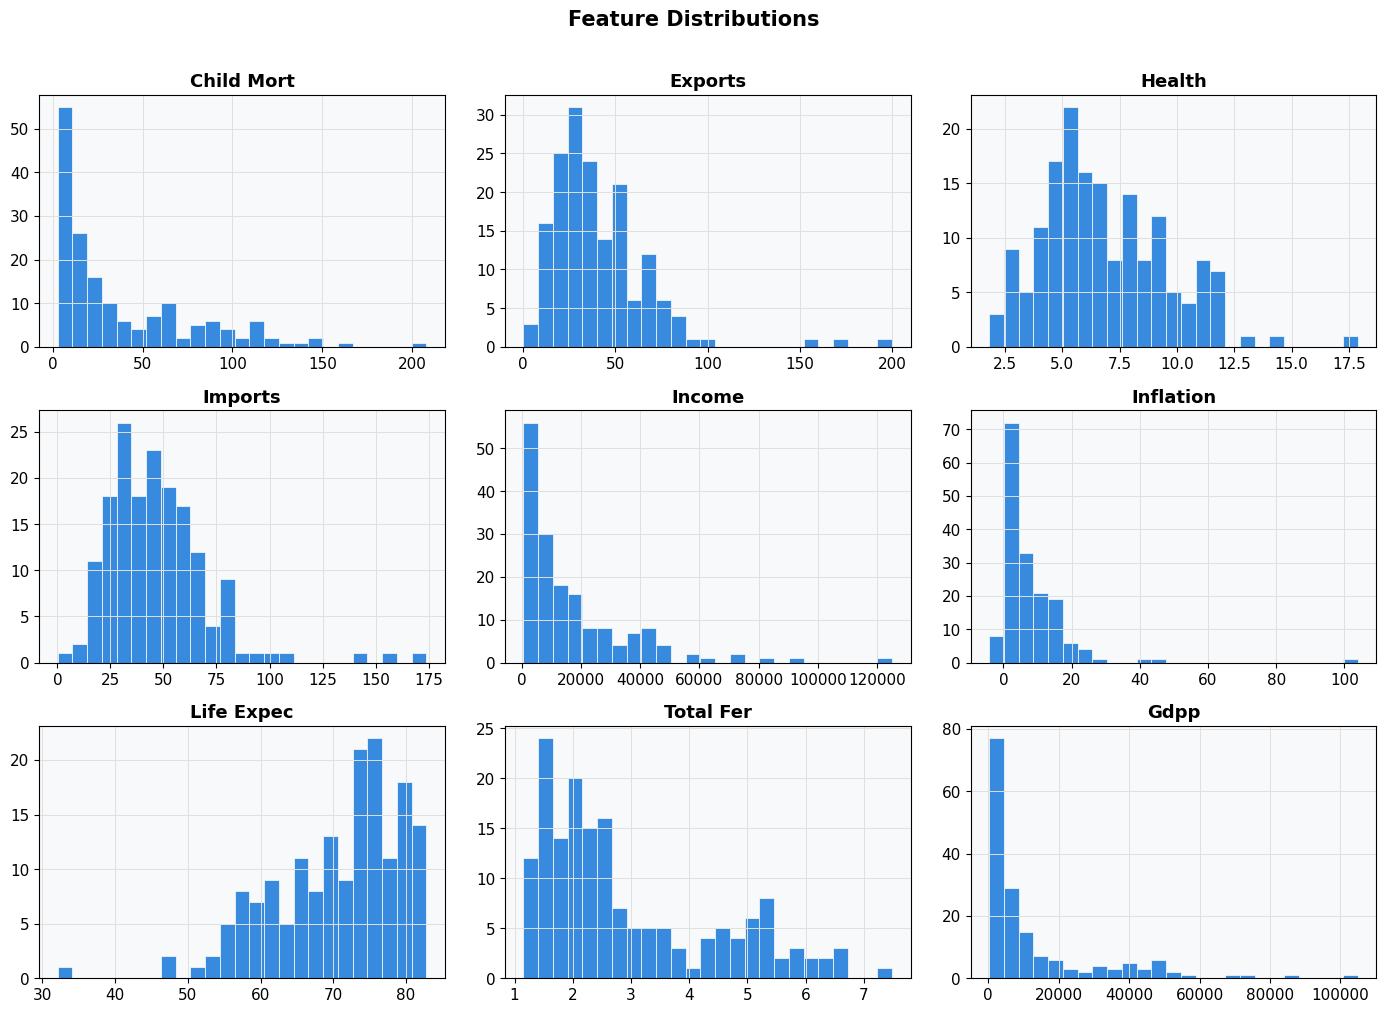

In [24]:
# Feature distributions
features = ['child_mort', 'exports', 'health', 'imports',
            'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
fig.suptitle('Feature Distributions', fontsize=15, fontweight='bold', y=1.01)

for ax, feat in zip(axes.flat, features):
    ax.hist(df[feat], bins=25, color='#378ADD', edgecolor='white', linewidth=0.5)
    ax.set_title(feat.replace('_', ' ').title())
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

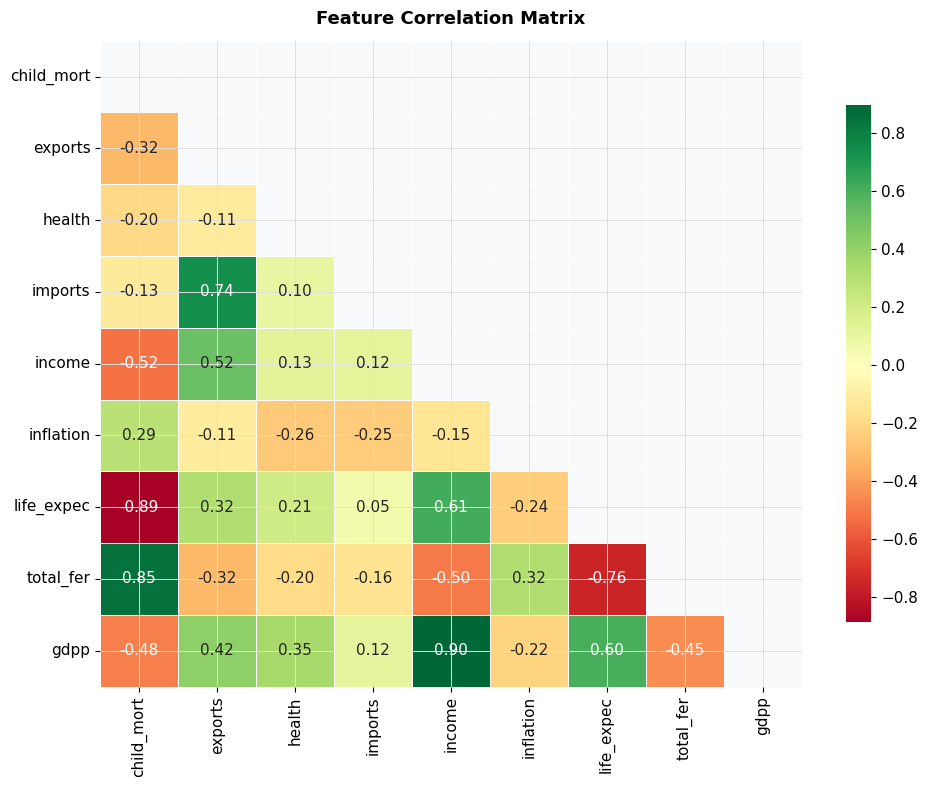

In [25]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature Correlation Matrix', pad=12)
plt.tight_layout()
plt.show()

In [26]:
# Composite development score (weighted blend of 4 key indicators)
df['dev_score'] = (
    (1 - df['child_mort']  / df['child_mort'].max()) * 0.30 +
    (df['life_expec']      / df['life_expec'].max()) * 0.25 +
    (df['income']          / df['income'].max())     * 0.25 +
    (df['gdpp']            / df['gdpp'].max())       * 0.20
)

# Bin into 3 development tiers
df['dev_category'] = pd.cut(
    df['dev_score'],
    bins=3,
    labels=['Underdeveloped', 'Developing', 'Developed']
)

print('Class distribution:')
print(df['dev_category'].value_counts())

# Encode target
le = LabelEncoder()
y = le.fit_transform(df['dev_category'])
label_names = list(le.classes_)
print(f'\nLabel mapping: {dict(zip(range(3), label_names))}')

Class distribution:
dev_category
Developing        113
Developed          28
Underdeveloped     26
Name: count, dtype: int64

Label mapping: {0: 'Developed', 1: 'Developing', 2: 'Underdeveloped'}


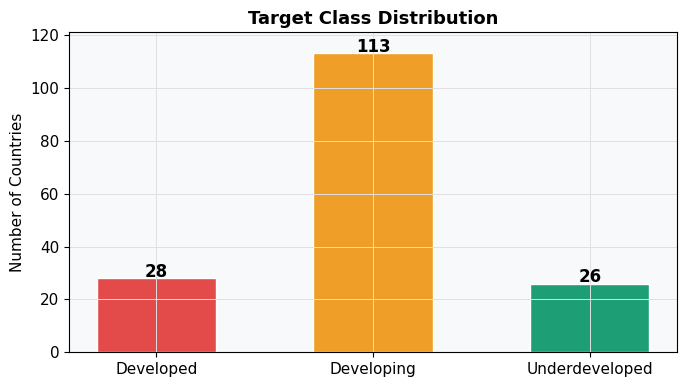

In [27]:
# Class distribution bar chart
counts = df['dev_category'].value_counts().reindex(label_names)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(label_names, counts.values, color=PALETTE, edgecolor='white', width=0.55)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(v), ha='center', fontweight='bold', fontsize=12)
ax.set_title('Target Class Distribution')
ax.set_ylabel('Number of Countries')
ax.set_ylim(0, max(counts.values) + 8)
plt.tight_layout()
plt.show()

In [28]:
X = df[features].copy()

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train set : {X_train.shape[0]} samples')
print(f'Test  set : {X_test.shape[0]} samples')

Train set : 133 samples
Test  set : 34 samples


In [29]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=8,
    random_state=42, class_weight='balanced'
)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)
rf_cv   = cross_val_score(rf, X_scaled, y, cv=5, scoring='accuracy')

print(f'Test Accuracy : {rf_acc:.4f}')
print(f'CV Accuracy   : {rf_cv.mean():.4f} ± {rf_cv.std():.4f}')
print()
print(classification_report(y_test, rf_pred, target_names=label_names))

Test Accuracy : 1.0000
CV Accuracy   : 0.9642 ± 0.0345

                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00         6
    Developing       1.00      1.00      1.00        23
Underdeveloped       1.00      1.00      1.00         5

      accuracy                           1.00        34
     macro avg       1.00      1.00      1.00        34
  weighted avg       1.00      1.00      1.00        34



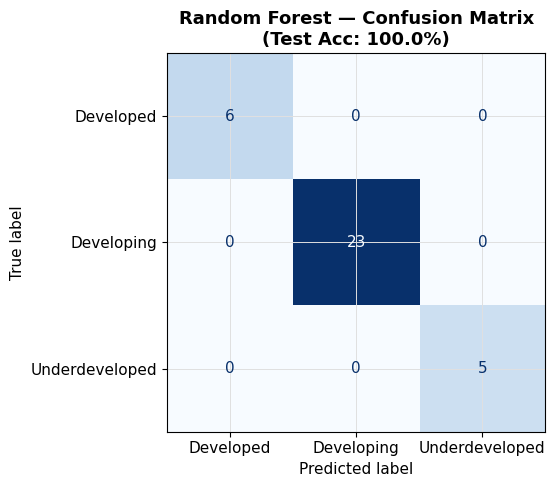

In [30]:
# Random Forest confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, rf_pred),
    display_labels=label_names
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Random Forest — Confusion Matrix\n(Test Acc: {rf_acc:.1%})')
plt.tight_layout()
plt.show()

In [31]:
xgb = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    random_state=42, eval_metric='mlogloss', verbosity=0
)
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_acc  = accuracy_score(y_test, xgb_pred)
xgb_cv   = cross_val_score(xgb, X_scaled, y, cv=5, scoring='accuracy')

print(f'Test Accuracy : {xgb_acc:.4f}')
print(f'CV Accuracy   : {xgb_cv.mean():.4f} ± {xgb_cv.std():.4f}')
print()
print(classification_report(y_test, xgb_pred, target_names=label_names))

Test Accuracy : 0.9706
CV Accuracy   : 0.9640 ± 0.0223

                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00         6
    Developing       0.96      1.00      0.98        23
Underdeveloped       1.00      0.80      0.89         5

      accuracy                           0.97        34
     macro avg       0.99      0.93      0.96        34
  weighted avg       0.97      0.97      0.97        34



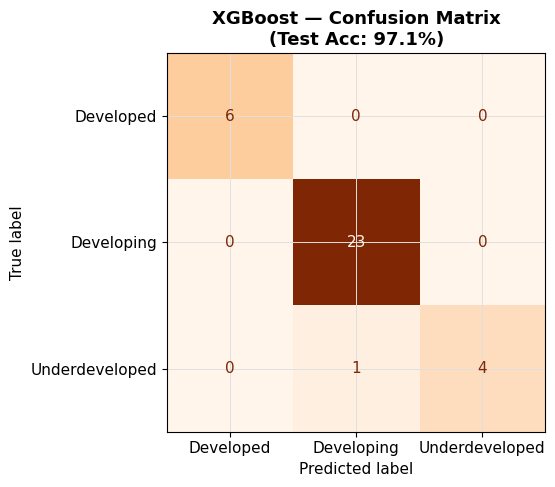

In [32]:
# XGBoost confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, xgb_pred),
    display_labels=label_names
).plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title(f'XGBoost — Confusion Matrix\n(Test Acc: {xgb_acc:.1%})')
plt.tight_layout()
plt.show()

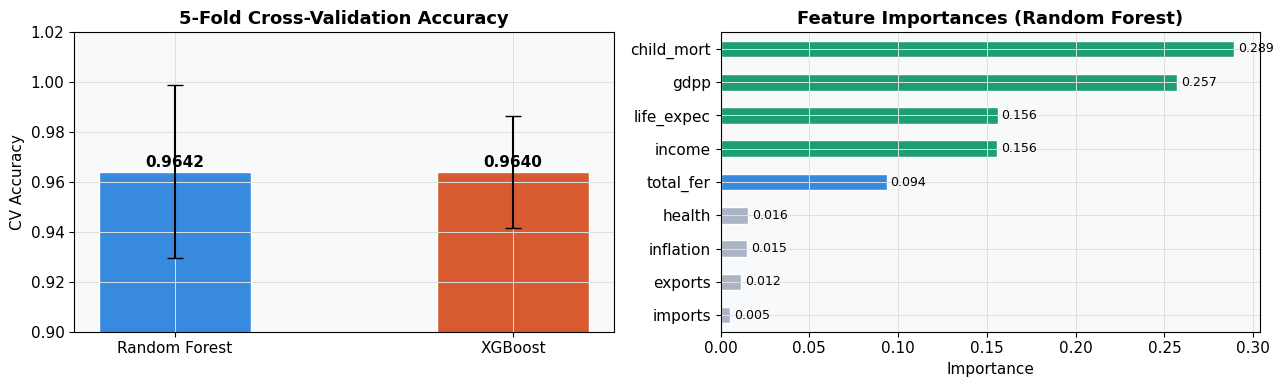

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# CV score comparison
ax = axes[0]
models  = ['Random Forest', 'XGBoost']
cv_means = [rf_cv.mean(), xgb_cv.mean()]
cv_stds  = [rf_cv.std(),  xgb_cv.std()]
bars = ax.bar(models, cv_means, yerr=cv_stds, color=['#378ADD', '#D85A30'],
              edgecolor='white', width=0.45, capsize=6)
ax.set_ylim(0.90, 1.02)
ax.set_ylabel('CV Accuracy')
ax.set_title('5-Fold Cross-Validation Accuracy')
for bar, m in zip(bars, cv_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{m:.4f}', ha='center', fontsize=11, fontweight='bold')

# Feature importances
ax = axes[1]
fi   = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)
colors = ['#1D9E75' if v > 0.1 else '#378ADD' if v > 0.05 else '#aab4c4' for v in fi.values]
fi.plot.barh(ax=ax, color=colors, edgecolor='white')
ax.set_title('Feature Importances (Random Forest)')
ax.set_xlabel('Importance')
for i, v in enumerate(fi.values):
    ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

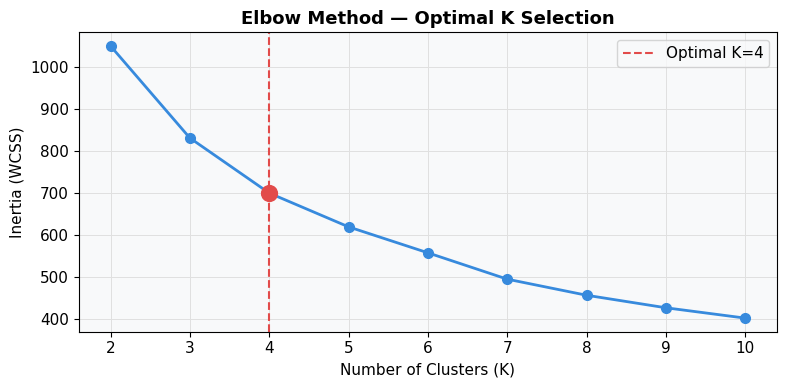

Inertias: {2: 1050, 3: 831, 4: 701, 5: 620, 6: 558, 7: 496, 8: 458, 9: 428, 10: 403}


In [34]:
inertias = []
K_range  = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(K_range), inertias, 'o-', color='#378ADD', linewidth=2, markersize=7)
ax.axvline(x=4, color='#E24B4A', linestyle='--', linewidth=1.5, label='Optimal K=4')
ax.scatter([4], [inertias[2]], s=130, color='#E24B4A', zorder=5)
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia (WCSS)')
ax.set_title('Elbow Method — Optimal K Selection')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Inertias: {dict(zip(K_range, [round(i) for i in inertias]))}')

In [35]:
km_best = KMeans(n_clusters=4, random_state=42, n_init=10)
df['kmeans_cluster'] = km_best.fit_predict(X_scaled)

print('Cluster sizes:')
print(df['kmeans_cluster'].value_counts().sort_index())

# Cluster profiles
profile_cols = ['child_mort', 'gdpp', 'life_expec', 'income', 'total_fer']
cluster_profile = df.groupby('kmeans_cluster')[profile_cols].mean().round(1)
print('\nCluster Profiles:')
print(cluster_profile)

Cluster sizes:
kmeans_cluster
0    32
1    47
2    85
3     3
Name: count, dtype: int64

Cluster Profiles:
                child_mort     gdpp  life_expec   income  total_fer
kmeans_cluster                                                     
0                      5.2  42118.8        80.1  44021.9        1.8
1                     93.0   1922.4        59.2   3942.4        5.0
2                     21.7   6519.6        72.9  12671.4        2.3
3                      4.1  57566.7        81.4  64033.3        1.4


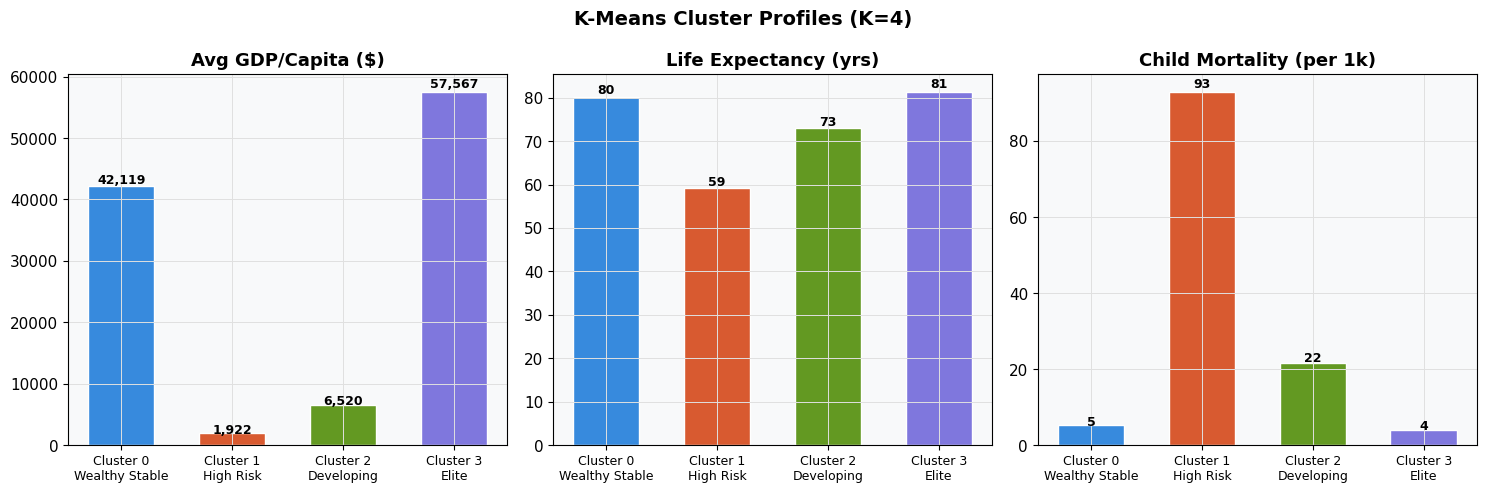

In [36]:
# Cluster profile radar / bar charts
cluster_names = [
    'Cluster 0\nWealthy Stable',
    'Cluster 1\nHigh Risk',
    'Cluster 2\nDeveloping',
    'Cluster 3\nElite'
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('K-Means Cluster Profiles (K=4)', fontsize=14, fontweight='bold')

metrics = [
    ('gdpp',       'Avg GDP/Capita ($)'),
    ('life_expec', 'Life Expectancy (yrs)'),
    ('child_mort', 'Child Mortality (per 1k)'),
]

for ax, (col, title) in zip(axes, metrics):
    vals = [cluster_profile.loc[i, col] for i in range(4)]
    bars = ax.bar(range(4), vals, color=KM_COLORS, edgecolor='white', width=0.6)
    ax.set_xticks(range(4))
    ax.set_xticklabels(cluster_names, fontsize=9)
    ax.set_title(title)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{v:,.0f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [37]:
# Sample countries per cluster
print('Sample countries per cluster:')
for i in range(4):
    countries = df[df['kmeans_cluster'] == i]['country'].tolist()[:10]
    print(f'\nCluster {i} ({cluster_names[i].replace(chr(10), " ")}):')
    print('  ', ', '.join(countries))

Sample countries per cluster:

Cluster 0 (Cluster 0 Wealthy Stable):
   Australia, Austria, Bahamas, Belgium, Brunei, Canada, Cyprus, Czech Republic, Denmark, Finland

Cluster 1 (Cluster 1 High Risk):
   Afghanistan, Angola, Benin, Botswana, Burkina Faso, Burundi, Cameroon, Central African Republic, Chad, Comoros

Cluster 2 (Cluster 2 Developing):
   Albania, Algeria, Antigua and Barbuda, Argentina, Armenia, Azerbaijan, Bahrain, Bangladesh, Barbados, Belarus

Cluster 3 (Cluster 3 Elite):
   Luxembourg, Malta, Singapore


In [38]:
db = DBSCAN(eps=2.5, min_samples=4)
df['dbscan_cluster'] = db.fit_predict(X_scaled)

n_clusters_db = len(set(df['dbscan_cluster'])) - (1 if -1 in df['dbscan_cluster'].values else 0)
n_noise       = (df['dbscan_cluster'] == -1).sum()

print(f'DBSCAN clusters found : {n_clusters_db}')
print(f'Noise points          : {n_noise}')
print()
print('Cluster sizes (−1 = noise):')
print(df['dbscan_cluster'].value_counts().sort_index())

print()
if n_noise > 0:
    noise_countries = df[df['dbscan_cluster'] == -1][['country', 'gdpp', 'child_mort']]
    print('Outlier countries (noise):')
    print(noise_countries.to_string(index=False))

DBSCAN clusters found : 1
Noise points          : 6

Cluster sizes (−1 = noise):
dbscan_cluster
-1      6
 0    161
Name: count, dtype: int64

Outlier countries (noise):
   country   gdpp  child_mort
     Haiti    662       208.0
Luxembourg 105000         2.8
     Malta  21100         6.8
   Nigeria   2330       130.0
     Qatar  70300         9.0
 Singapore  46600         2.8


PC1 explains 46.0% of variance
PC2 explains 17.2% of variance
Total       63.1%


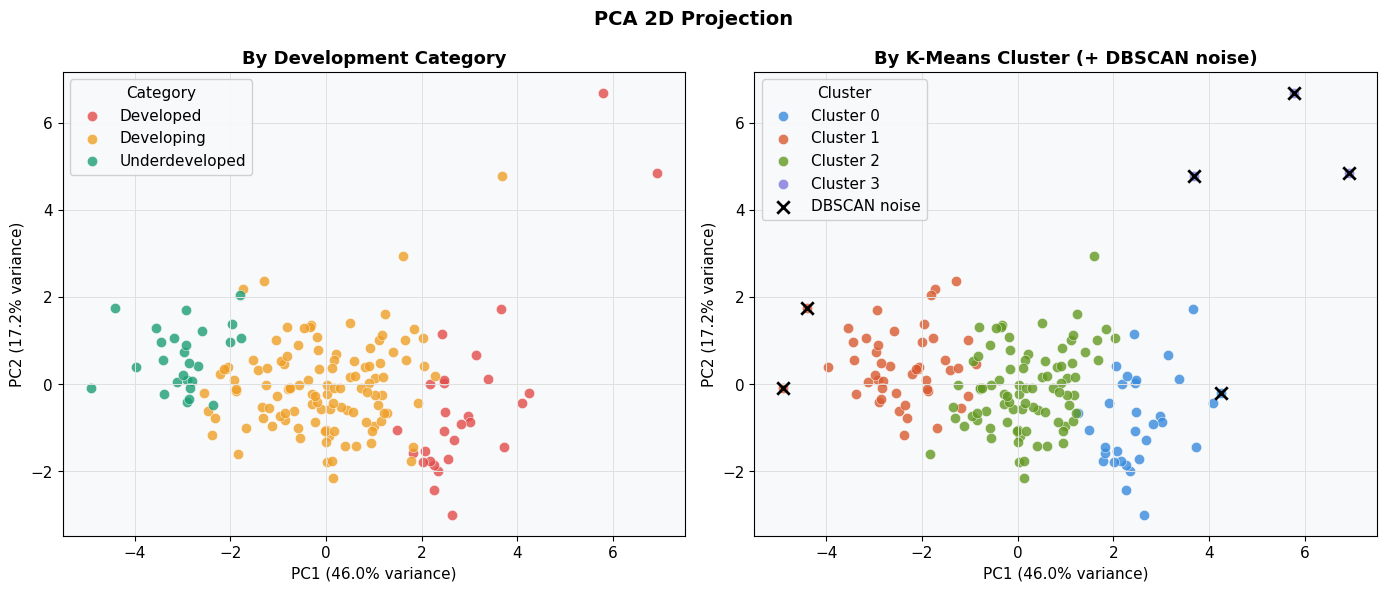

In [39]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

var1, var2 = pca.explained_variance_ratio_ * 100
print(f'PC1 explains {var1:.1f}% of variance')
print(f'PC2 explains {var2:.1f}% of variance')
print(f'Total       {var1+var2:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('PCA 2D Projection', fontsize=14, fontweight='bold')

# Left: colored by development category
ax = axes[0]
for i, (label, color) in enumerate(zip(label_names, PALETTE)):
    mask = y == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, label=label, s=55, alpha=0.8, edgecolors='white', linewidth=0.4)
ax.set_xlabel(f'PC1 ({var1:.1f}% variance)')
ax.set_ylabel(f'PC2 ({var2:.1f}% variance)')
ax.set_title('By Development Category')
ax.legend(title='Category', framealpha=0.9)

# Right: colored by K-Means cluster
ax = axes[1]
for i, color in enumerate(KM_COLORS):
    mask = df['kmeans_cluster'] == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, label=f'Cluster {i}', s=55, alpha=0.8,
               edgecolors='white', linewidth=0.4)
# Highlight DBSCAN noise
noise_mask = df['dbscan_cluster'] == -1
if noise_mask.any():
    ax.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1],
               c='black', marker='x', s=80, linewidths=2, label='DBSCAN noise', zorder=5)
ax.set_xlabel(f'PC1 ({var1:.1f}% variance)')
ax.set_ylabel(f'PC2 ({var2:.1f}% variance)')
ax.set_title('By K-Means Cluster (+ DBSCAN noise)')
ax.legend(title='Cluster', framealpha=0.9)

plt.tight_layout()
plt.show()